## Evaluate ERA-Interim Cross validation


In [3]:
import os
import sys

import numpy as np
import pandas as pd
import xarray as xr
import colorcet as cc
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

base_dir = os.path.dirname(os.path.abspath('')).split(os.sep + 'eval_transferability')[0]

sys.path.append(os.path.sep.join([base_dir , 'src']))
from help_fcts import get_rmse, get_mae, get_mbe, get_r2, calc_anomaly

fig_dir = os.path.sep.join([base_dir, 'figures_transf', 'CESM2'])
os.makedirs(fig_dir, exist_ok=True)

In [4]:
# load daily melt predictions
chunking = {'time': -1, 'y': -1, 'x': -1}
pred_dir = os.path.sep.join([base_dir, 'output', 'crossval_ERAI_modularNNEBM'])
pred_dir = os.path.sep.join([base_dir, 'output', 'crossval_CESM2_modularNNEBM_mse'])


# load climatology of true melt
#ds_clim = xr.open_dataset(os.path.sep.join([base_dir, 'data', 'interim', 'ERAI', 'HIRHAM5', 'firnpack', 'climat_snmel_1990-2013_smoothed15.nc']))
ds_clim = xr.open_dataset(os.path.sep.join([base_dir, 'data', 'interim', 'CESM2', 'HIRHAM5', 'firnpack', 'climat_1990-2013_smoothed15.nc']))
snmel_clim = ds_clim['snmel']#.sel(x=ds_pred['x'], y=ds_pred['y'])
snmel_clim


<xarray.DataArray 'snmel' (time: 366, y: 602, x: 402)> Size: 354MB
[88573464 values with dtype=float32]
Coordinates:
    lon      (y, x) float32 968kB ...
    lat      (y, x) float32 968kB ...
  * x        (x) float64 3kB 0.0 1.0 2.0 3.0 4.0 ... 398.0 399.0 400.0 401.0
  * y        (y) float64 5kB 0.0 1.0 2.0 3.0 4.0 ... 598.0 599.0 600.0 601.0
  * time     (time) datetime64[ns] 3kB 1980-01-01T12:00:00 ... 1980-12-31T12:...
Attributes:
    long_name:  Acc snow melt
    units:      mm/day weq
    height:     0.0
    time:       365.75

In [9]:
# def calc_anomaly(ds, clim):
#     md_clim = clim['time'].dt.strftime('%m-%d')        # DataArray of strings length 366
#     clim = clim.assign_coords(md=md_clim)              # attach md coordinate to the DataArray

#     # 2. group by the md coordinate and average (should give one value per md per spatial point)
#     clim = clim.groupby('md').mean(dim='time')   # dims: ('md', spatial...)

#     # 3. prepare the main data: build md for every day; map 02-29 -> 02-28 if desired
#     # da = ds_melt.set_index(z=['y', 'x']).unstack('z').transpose('time', 'y', 'x')

#     md_data = ds['time'].dt.strftime('%m-%d')
#     #md_data_fixed = md_data.where(md_data != '02-29', other='02-28')  # simple leap-day treatment
#     ds = ds.assign_coords(md=('time', md_data.values))         # attach md coord to data

#     # 4. subtract: groupby on md aligns with clim_by_md's md coordinate; broadcasting happens automatically
#     anomaly = (ds.groupby('md') - clim).compute()

#     return anomaly, clim, ds

In [10]:
# # predict anomalies for 2016 w.r.t. climatology 1990-2013

# ds_clim = ds_clim.sel(x=ds_pred['x'].astype(int), y=ds_pred['y'].astype(int))

# pred_da = ds_pred['snmel_pred'].sel(time=slice('1990-01-01','2016-12-31')).compute()
# true_da = ds_pred['snmel_true'].sel(time=slice('1990-01-01','2016-12-31')).compute()

# anomaly_pred, _, _ = calc_anomaly(pred_da, ds_clim['snmel'])
# anomaly_true, _, _ = calc_anomaly(true_da, ds_clim['snmel'])

## Basin-wise Scores of Modular NN

In [5]:
# Tables 5: Basin-wise scores per year
# this takes a few minutes ...

years = range(2002, 2017, 2)
iter_n = range(5)
scaling_factor = 1.796553703424 / 58391 

metrics = ['total melt', 'RMSE', 'MAE', 'MBE', 'R2', 'R2_anomalies']

# Create multi-level index (years × categories)
index = pd.MultiIndex.from_product([years, iter_n], names=['year', 'iter'])

# Create DataFrame with this index and metric columns
df_per_year = pd.DataFrame(np.nan,  index=index, dtype=float, 
    columns=metrics)

for year in years:
    for it in iter_n:
        try:
            data_dir = os.path.sep.join([pred_dir, f'fold_{year}', f'iter_{it}', 'pred_val.zarr'])
            print(f'Load data {data_dir} ...')
            ds_pred = xr.open_dataset(data_dir).chunk(chunking)
            pred_da = ds_pred['snmel_pred'].compute()
            true_da = ds_pred['snmel_true'].compute()

            residual = pred_da - true_da
            total_melt = true_da.sum(dim=['time','x','y']).item()*scaling_factor
            df_per_year.loc[(year,it), 'total melt'] = total_melt
            df_per_year.loc[(year,it), 'RMSE'] = get_rmse(residual)
            df_per_year.loc[(year,it), 'MAE'] = get_mae(residual)
            df_per_year.loc[(year,it), 'MBE'] = get_mbe(residual)
            df_per_year.loc[(year,it), 'R2'] = get_r2(true_da.values, pred_da.values)

            #print('Calculate anomalies')
            anomaly_pred, _, _ = calc_anomaly(pred_da, ds_clim['snmel'].sel(x=ds_pred['x'].astype(int), y=ds_pred['y'].astype(int)))
            anomaly_true, _, _ = calc_anomaly(true_da, ds_clim['snmel'].sel(x=ds_pred['x'].astype(int), y=ds_pred['y'].astype(int)))
            df_per_year.loc[(year,it), 'R2_anomalies'] = get_r2(anomaly_true.values, anomaly_pred.values)
        except Exception as e:
            pass

display(df_per_year.round(2))

Load data /home/eschlager/MeltEmulation/output/crossval_CESM2_modularNNEBM_mse/fold_2002/iter_0/pred_val.zarr ...
Load data /home/eschlager/MeltEmulation/output/crossval_CESM2_modularNNEBM_mse/fold_2002/iter_1/pred_val.zarr ...
Load data /home/eschlager/MeltEmulation/output/crossval_CESM2_modularNNEBM_mse/fold_2002/iter_2/pred_val.zarr ...
Load data /home/eschlager/MeltEmulation/output/crossval_CESM2_modularNNEBM_mse/fold_2002/iter_3/pred_val.zarr ...
Load data /home/eschlager/MeltEmulation/output/crossval_CESM2_modularNNEBM_mse/fold_2002/iter_4/pred_val.zarr ...
Load data /home/eschlager/MeltEmulation/output/crossval_CESM2_modularNNEBM_mse/fold_2004/iter_0/pred_val.zarr ...
Load data /home/eschlager/MeltEmulation/output/crossval_CESM2_modularNNEBM_mse/fold_2004/iter_1/pred_val.zarr ...
Load data /home/eschlager/MeltEmulation/output/crossval_CESM2_modularNNEBM_mse/fold_2004/iter_2/pred_val.zarr ...
Load data /home/eschlager/MeltEmulation/output/crossval_CESM2_modularNNEBM_mse/fold_2004

total melt  RMSE   MAE   MBE    R2  R2_anomalies
year iter                                                  
2002 0         939.04  1.20  0.31  0.04  0.95          0.72
     1         939.04  1.19  0.33  0.05  0.95          0.72
     2         939.04  1.16  0.31 -0.02  0.95          0.74
     3         939.04  1.20  0.34  0.04  0.95          0.72
     4            NaN   NaN   NaN   NaN   NaN           NaN
2004 0         925.62  1.24  0.34 -0.02  0.95          0.76
     1         925.62  1.26  0.39  0.02  0.95          0.75
     2         925.62  1.28  0.34 -0.05  0.94          0.75
     3         925.62  1.24  0.32  0.01  0.95          0.76
     4         925.62  1.24  0.33 -0.01  0.95          0.76
2006 0        1139.17  1.31  0.37 -0.03  0.96          0.80
     1        1139.17  1.32  0.36 -0.02  0.96          0.80
     2        1139.17  1.33  0.34 -0.06  0.95          0.79
     3        1139.17  1.35  0.38 -0.03  0.95          0.79
     4        1139.17  1.37  0.40  0.00  0.95          0.78
2008 0         766.92  1.42  0.41  0.27  0.91          0.64
     1         766.92  1.34  0.35  0.20  0.92          0.68
     2         766.92  1.28  0.31  0.15  0.93          0.71
     3         766.92  1.26  0.32  0.14  0.93          0.72
     4         766.92  1.38  0.38  0.22  0.91          0.66
2010 0        1040.59  1.59  0.38 -0.15  0.93          0.70
     1        1040.59  1.51  0.44  0.07  0.94          0.73
     2        1040.59  1.45  0.37 -0.05  0.94          0.75
     3        1040.59  1.47  0.35 -0.09  0.94          0.74
     4        1040.59  1.44  0.35 -0.10  0.94          0.75
2012 0        1200.40  1.38  0.37 -0.03  0.95          0.77
     1        1200.40  1.40  0.38 -0.01  0.95          0.76
     2        1200.40  1.36  0.39  0.03  0.95          0.78
     3        1200.40  1.39  0.38 -0.09  0.95          0.77
     4        1200.40  1.40  0.37 -0.08  0.95          0.76
2014 0        1209.24  1.39  0.37 -0.06  0.95          0.76
     1        1209.24  1.39  0.42  0.07  0.95          0.76
     2        1209.24  1.39  0.42  0.09  0.95          0.76
     3        1209.24  1.38  0.37 -0.01  0.95          0.77
     4        1209.24  1.41  0.39 -0.00  0.95          0.76
2016 0         862.67  1.53  0.40  0.20  0.91          0.71
     1         862.67  1.53  0.43  0.23  0.91          0.70
     2         862.67  1.46  0.39  0.23  0.92          0.73
     3         862.67  1.52  0.42  0.25  0.91          0.71
     4         862.67  1.52  0.38  0.22  0.91          0.71

In [7]:
# mean and std across all years
stats = df_per_year.groupby(level='year').agg(['mean', 'std'])
display(stats.round(2))

total melt       RMSE         MAE         MBE          R2        \
           mean  std  mean   std  mean   std  mean   std  mean   std   
year                                                                   
2002     939.04  0.0  1.19  0.02  0.32  0.01  0.03  0.03  0.95  0.00   
2004     925.62  0.0  1.25  0.02  0.34  0.03 -0.01  0.03  0.95  0.00   
2006    1139.17  0.0  1.34  0.02  0.37  0.02 -0.03  0.02  0.95  0.00   
2008     766.92  0.0  1.33  0.07  0.36  0.04  0.20  0.05  0.92  0.01   
2010    1040.59  0.0  1.49  0.06  0.38  0.04 -0.06  0.08  0.94  0.01   
2012    1200.40  0.0  1.39  0.02  0.38  0.01 -0.04  0.05  0.95  0.00   
2014    1209.24  0.0  1.39  0.01  0.39  0.03  0.02  0.06  0.95  0.00   
2016     862.67  0.0  1.51  0.03  0.41  0.02  0.23  0.02  0.91  0.00   

     R2_anomalies        
             mean   std  
year                     
2002         0.72  0.01  
2004         0.76  0.01  
2006         0.79  0.01  
2008         0.68  0.03  
2010         0.73  0.02  
2012         0.77  0.01  
2014         0.76  0.00  
2016         0.71  0.01

In [8]:
stats_all = df_per_year.agg(['mean', 'std'])
stats_all

,total melt,RMSE,MAE,MBE,R2,R2_anomalies
mean,1012.286242,1.365411,0.369826,0.041310,0.939689,0.741592
std,156.217560,0.107535,0.035178,0.113026,0.015094,0.036644


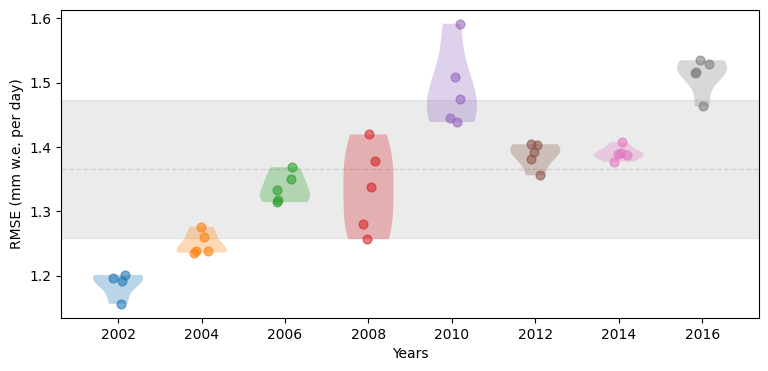

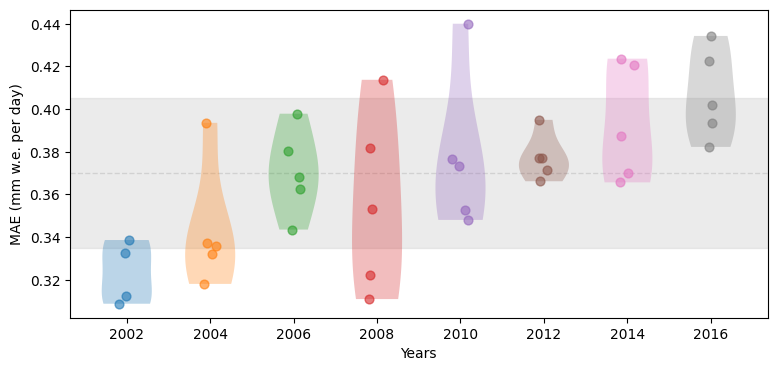

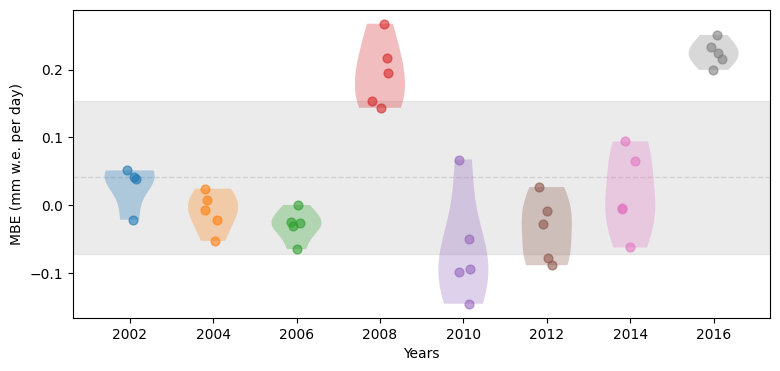

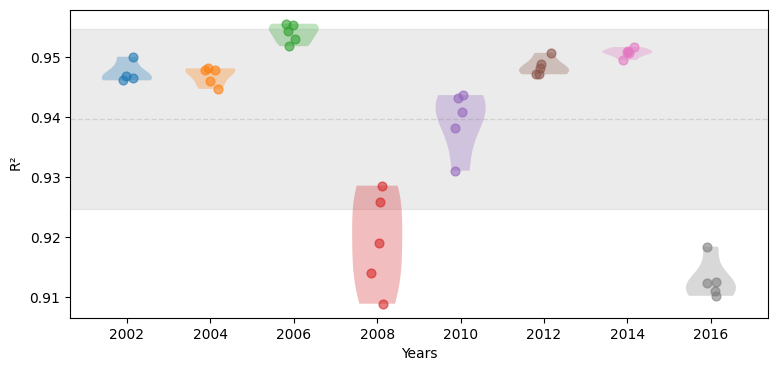

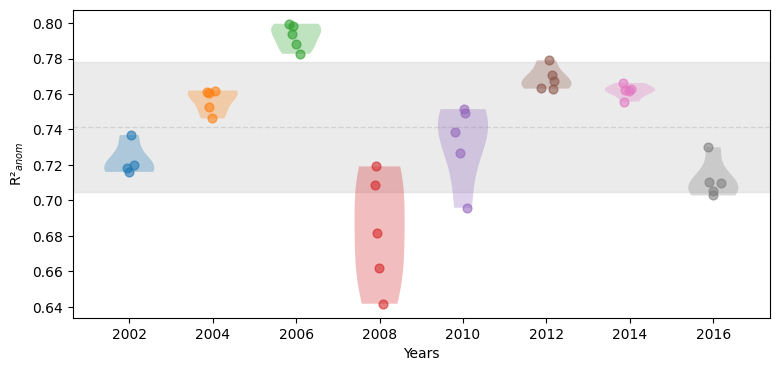

In [9]:
import seaborn as sns
cmap = mcolors.ListedColormap(cc.glasbey_category10)
colors = cmap.colors

for metric_to_plot in ['RMSE', 'MAE', 'MBE', 'R2', 'R2_anomalies']:
    fig, ax = plt.subplots(figsize=(9,4))
    ax.axhline(y=stats_all[metric_to_plot]['mean'], color='silver', alpha=0.6, linestyle='--', linewidth=1, zorder=-5)
    ax.axhspan(ymin=stats_all[metric_to_plot]['mean']-stats_all[metric_to_plot]['std'], ymax=stats_all[metric_to_plot]['mean']+stats_all[metric_to_plot]['std'], 
               color='silver', alpha=0.3)
    for i,bb in enumerate(years):
        dff = df_per_year.xs(bb, level='year')[metric_to_plot]
        dff_train = dff.loc[:2014].dropna()
        #ax.boxplot(dff_train.values, positions=[i], widths=0.6)
        #vp = ax.violinplot(data=dff_train, inner="point", density_norm="count")
        vp = ax.violinplot(dff_train.values, positions=[i], widths=0.6, showmedians=False, showextrema=False)
        for pc in vp['bodies']:
            pc.set_facecolor(colors[i])
            pc.set_alpha(0.3)  # 0.5 = 50% transparent
        plt.scatter((np.random.rand(len(dff_train)))*0.2+i-0.1, dff_train.values, s=40, color=colors[i], linewidth=None, alpha=0.6)
        
        # plt.scatter(i-0.1, dff[2015], marker='D', color=colors[i], edgecolor='k', s=35, linewidth=.5, label='2015')
        # plt.scatter(i+0.1, dff[2014], marker='X', color=colors[i], edgecolor='k', s=50, linewidth=.5, label='2014')
        # plt.scatter(i, dff[2016], marker='*', color='k', edgecolor='k', s=70, linewidth=.5, label='2016')

        ax.set_xticks(np.arange(len(years)))
        ax.set_xticklabels(years)


        ax.set_xticks(np.arange(len(years)))
        ax.set_xticklabels(years)
        if metric_to_plot=='R2':
            ax.set_ylabel('R$²$')
        elif metric_to_plot=='R2_anomalies':
            ax.set_ylabel('R$²_{anom}$')
        else:
            ax.set_ylabel(metric_to_plot+' (mm w.e. per day)')
        ax.set_xlabel('Years')
        fig.savefig(os.path.sep.join([fig_dir, f"crossval_violinplot{metric_to_plot}.png"]), bbox_inches='tight', dpi=200)

    plt.show()

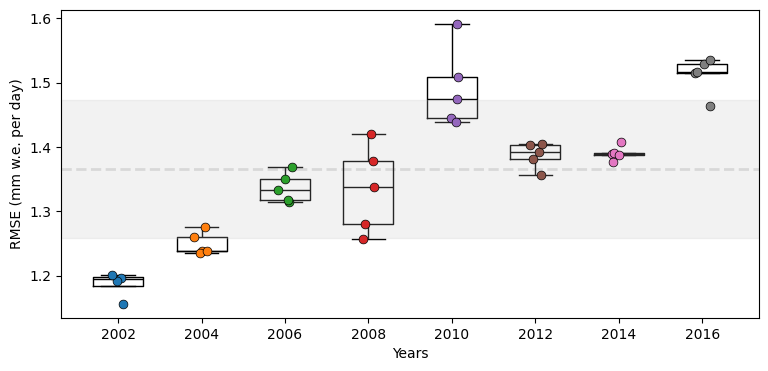

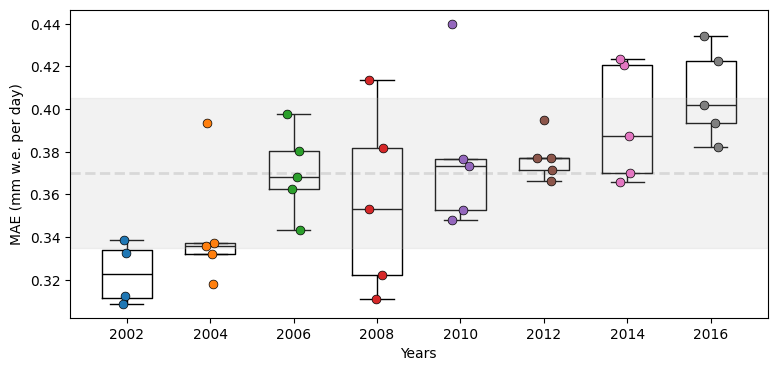

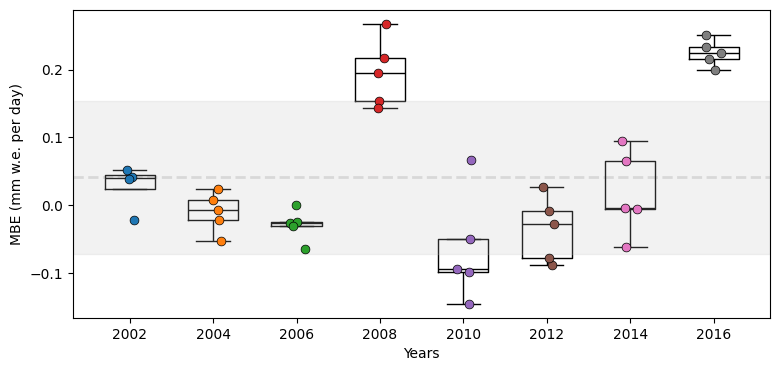

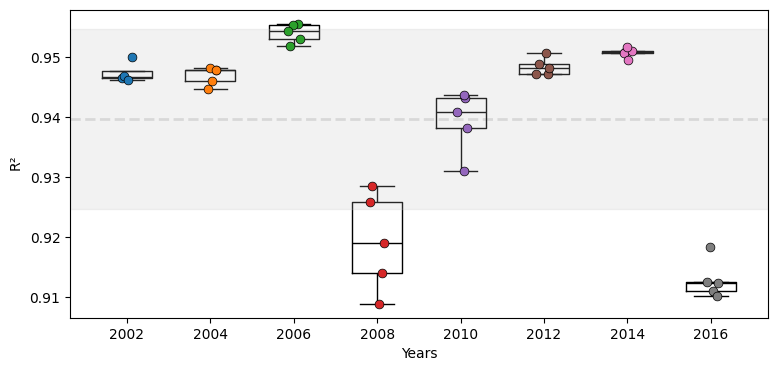

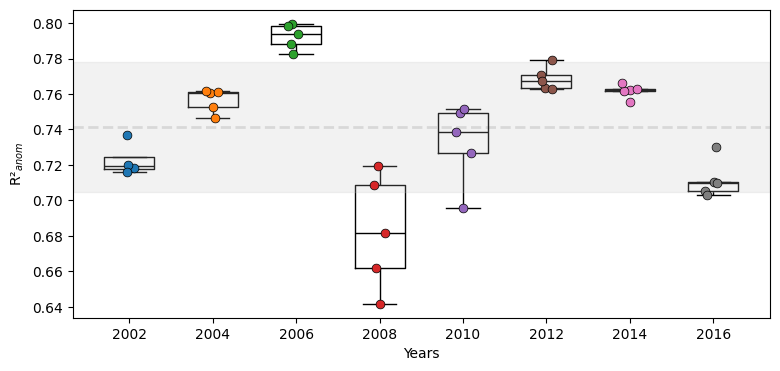

In [10]:
import seaborn as sns
cmap = mcolors.ListedColormap(cc.glasbey_category10)
colors = cmap.colors

for metric_to_plot in ['RMSE', 'MAE', 'MBE', 'R2', 'R2_anomalies']:
    fig, ax = plt.subplots(figsize=(9,4))
    ax.axhline(y=stats_all[metric_to_plot]['mean'], color='silver', alpha=0.5, linestyle='--', linewidth=2, zorder=-5)
    ax.axhspan(ymin=stats_all[metric_to_plot]['mean']-stats_all[metric_to_plot]['std'], ymax=stats_all[metric_to_plot]['mean']+stats_all[metric_to_plot]['std'], 
               color='silver', alpha=0.2)
    for i,bb in enumerate(years):
        dff = df_per_year.xs(bb, level='year')[metric_to_plot]
        dff_train = dff.loc[:2014].dropna()
        #ax.boxplot(dff_train.values, positions=[i], widths=0.6)
        #vp = ax.violinplot(data=dff_train, inner="point", density_norm="count")
        vp = sns.boxplot(dff_train.values, positions=[i], showfliers=False, widths=0.6, fill=False, color='k', linewidth=1, ax=ax, zorder=-1)
        
        ax.scatter((np.random.rand(len(dff_train)))*0.2+i-0.1, dff_train.values, s=40, color=colors[i], linewidth=0.5, edgecolors='k', alpha=1., zorder=1)
        
        # plt.scatter(i-0.1, dff[2015], marker='D', color=colors[i], edgecolor='k', s=35, linewidth=.5, label='2015')
        # plt.scatter(i+0.1, dff[2014], marker='X', color=colors[i], edgecolor='k', s=50, linewidth=.5, label='2014')
        # plt.scatter(i, dff[2016], marker='*', color='k', edgecolor='k', s=70, linewidth=.5, label='2016')

        ax.set_xticks(np.arange(len(years)))
        ax.set_xticklabels(years)


        ax.set_xticks(np.arange(len(years)))
        ax.set_xticklabels(years)
        if metric_to_plot=='R2':
            ax.set_ylabel('R$²$')
        elif metric_to_plot=='R2_anomalies':
            ax.set_ylabel('R$²_{anom}$')
        else:
            ax.set_ylabel(metric_to_plot+' (mm w.e. per day)')
        ax.set_xlabel('Years')
        fig.savefig(os.path.sep.join([fig_dir, f"crossval_boxplot{metric_to_plot}.png"]), bbox_inches='tight', dpi=200)

    plt.show()

In [60]:
# from matplotlib.lines import Line2D
# import matplotlib.pyplot as plt

# legend_elements = [
#     Line2D([0], [0], marker='o', color='w', markerfacecolor='grey', 
#             markersize=8, label='1990-2013'),
#     Line2D([0], [0], marker='X', color='w', markerfacecolor='grey', 
#             markeredgecolor='k', markersize=7, label='2014'),
#     Line2D([0], [0], marker='D', color='w', markerfacecolor='grey', 
#             markeredgecolor='k', markersize=6, label='2015'),
#     Line2D([0], [0], marker='*', color='w', markerfacecolor='k', 
#             markeredgecolor='k', markersize=8, label='2016'),
# ]

# # Create a separate figure for the legend only
# fig_legend = plt.figure(figsize=(8, 1))
# ax_legend = fig_legend.add_subplot(111)
# ax_legend.axis('off')  # Hide the axes

# legend = ax_legend.legend(handles=legend_elements, ncols=4, loc='center', 
#                           frameon=True, fontsize=12)

# fig_legend.savefig(os.path.sep.join([fig_dir, f"modularNN_EBM_violinplot_legend.png"]), bbox_inches='tight', dpi=200)

In [17]:
import os
pred_dir = os.path.sep.join([base_dir, 'output', 'crossval_CESM2_modularNNEBM_mse'])
data_dir = os.path.sep.join([pred_dir, f'fold_2016', f'iter_0', 'pred_val.zarr'])
print(f'Load data {data_dir} ...')
chunking = {'time': -1, 'y': -1, 'x': -1}
ds_pred = xr.open_dataset(data_dir).chunk(chunking)#.sel(time=slice('2016-01-01','2016-12-31'))
pred_da = ds_pred['snmel_pred'].compute()
true_da = ds_pred['snmel_true'].compute()



Load data /home/eschlager/MeltEmulation/output/crossval_CESM2_modularNNEBM_mse/fold_2016/iter_0/pred_val.zarr ...


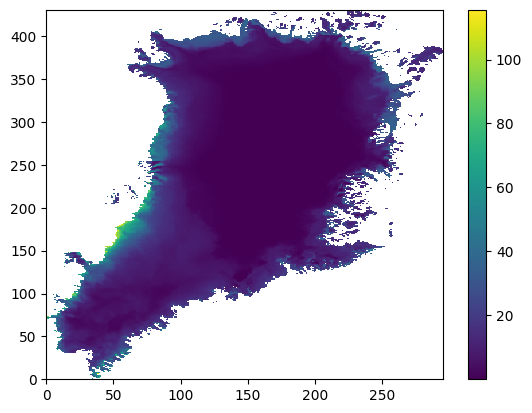

In [22]:
plt.pcolormesh(pred_da.isel(time=180))
plt.colorbar()

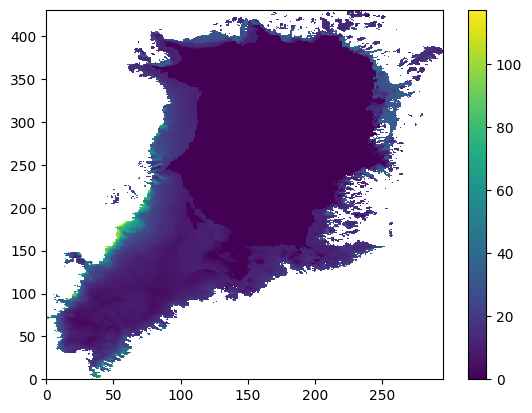

In [23]:
plt.pcolormesh(true_da.isel(time=180))
plt.colorbar()

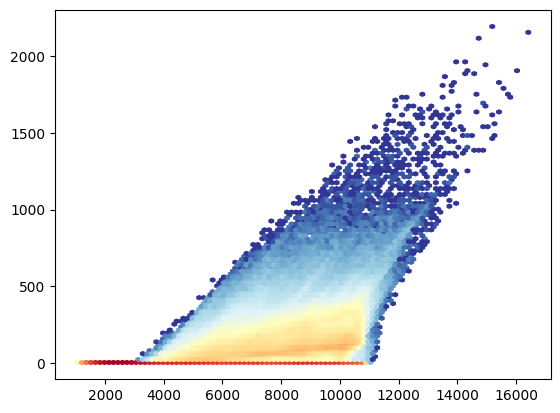

In [16]:
plt.hexbin(pred_da.values.flatten(), true_da.values.flatten(), bins='log', cmap='RdYlBu_r')